# Explanatory Data Analysis

In [3]:
import kagglehub
import pandas as pd

from pathlib import Path
import matplotlib.pyplot as plt

import numpy as np
from scipy.signal import find_peaks


c:\Users\egrac\github\NeuronZadanie\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Download latest version
path = kagglehub.dataset_download("danizo/eeg-dataset-for-adhd")

p = Path(path)



In [5]:
df = pd.read_csv(p/"adhdata.csv")

In [6]:
print(df.shape)

(2166383, 21)


## Opis datasetu i struktury

Dane składają się z 21 kolumn oraz 2 166 383 wierszy.

19 kanałów to elektrody pobierające sygnał EEG, ID to identyfikator pacjenta (choć błędnie nazwany, gdyż z datasetu wynika, że było 121 pacjentów, więc ID oznacza numer sesji badania, a niektóre sesje były powtarzane dla tych samych pacjentów).

Wiersze przedstawiają szeregi czasowe dla 350 prób, podczas których badano sygnały EEG u dzieci. Jednostką pomiaru był pV.

Klasa określa, czy dziecko ma ADHD, czy nie.

Uczestnicy to 61 dzieci z ADHD i 60 zdrowych kontrolnych (chłopcy i dziewczynki, w wieku 7-12 lat). Dzieci z ADHD zostały zdiagnozowane przez doświadczonego psychiatry zgodnie z kryteriami DSM-IV i przyjmowały Ritalin przez maksymalnie 6 miesięcy. Żadne z dzieci w grupie kontrolnej nie miało historii zaburzeń psychiatrycznych, epilepsji ani żadnych zgłoszeń ryzykownych zachowań.

Rejestracja EEG została wykonana zgodnie ze standardem 10-20 przy użyciu 19 kanałów (Fz, Cz, Pz, C3, T3, C4, T4, Fp1, Fp2, F3, F4, F7, F8, P3, P4, T5, T6, O1, O2) z częstotliwością próbkowania 128 Hz. Elektrody A1 i A2 były referencyjne, umieszczone na płatkach uszu.

## Sanity check 

Wartości sygnałów ustawiamy na inty, class jako zmienna kategoryczną.

Sprawdzanie braków danych realizujemy funkcją `isna`/`isnull`.

In [7]:
for col in df.columns[:-2]:
    df[col] = df[col].astype(int)
df["Class"] = df["Class"].astype("category")

## Kontrola jakości danych

Nie występują obserwacje odstające, podczas przeglądanai danych ,też nie wykryłem żadnego niestandardowego zapisy obserwacji brakujących.

In [8]:
print(df.isna().sum())

Fp1      0
Fp2      0
F3       0
F4       0
C3       0
C4       0
P3       0
P4       0
O1       0
O2       0
F7       0
F8       0
T7       0
T8       0
P7       0
P8       0
Fz       0
Cz       0
Pz       0
Class    0
ID       0
dtype: int64


Długości serii są bardzo różne, ze względu na to , że badania przeprowadzano do omomentu zakończenia odpowiedzi dziecka.

Częstotliwość próbkowania wynosiła 128Hz, czyli jeżeli podzielimy ilośc próbek w każdej sesji przez 128, to uzyskamy długość trawania sesji w sekundach.

In [9]:
print(max(df.groupby("ID").size())/128)
print(min(df.groupby("ID").size())/128)

337.90625
62.3671875


Najdłuższa zesja trwałą ok 5.5 minut a najkrutsza ok jednej minuty. Więc występują istotne różnice w długości trwanai sesji.

In [10]:
# oblicz długość sesji dla każdego ID w sekundach
lengths = df.groupby('ID').size() / 128

# pobierz klasę przypisaną do pierwszego wiersza każdej sesji (powinna być taka sama w obrębie ID)
classes = df.groupby('ID')['Class'].first()

# złącz i policz średnią długość w zależności od klasy
session_info = pd.concat([classes, lengths.rename('duration')], axis=1)
avg_by_class = session_info.groupby('Class')['duration'].mean()
print(avg_by_class)

Class
ADHD       154.593878
Control    124.910677
Name: duration, dtype: float64


Widać, że sesje średnio trwał dłużej dla dzieci z ADHD, niż bez niego

In [11]:
# rozszerz tabelę cech o dodatkowe cechy


# kanały EEG
channels = df.columns[:-2]

# cechy statystyczne, spektralne, nieliniowe dla każdego kanału w każdej sesji
features = []
for id_val in df['ID'].unique():
    session_data = df[df['ID'] == id_val]
    class_val = session_data['Class'].iloc[0]
    duration = len(session_data) / 128  # w sekundach
    row = {'ID': id_val, 'Class': class_val, 'duration': duration}
    for ch in channels:
        series = session_data[ch].values
        # statystyczne rozszerzone
        row[f'{ch}_mean'] = np.mean(series)
        row[f'{ch}_median'] = np.median(series)
        row[f'{ch}_std'] = np.std(series)
        row[f'{ch}_var'] = np.var(series)
        row[f'{ch}_min'] = np.min(series)
        row[f'{ch}_max'] = np.max(series)
        row[f'{ch}_skew'] = pd.Series(series).skew()
        row[f'{ch}_kurt'] = pd.Series(series).kurtosis()
        # RMS
        row[f'{ch}_rms'] = np.sqrt(np.mean(series**2))
        # energia (suma kwadratów)
        row[f'{ch}_energy'] = np.sum(series**2)
        # liczba pików (lokalne maksima)
        peaks, _ = find_peaks(series)
        row[f'{ch}_peaks'] = len(peaks)
        # spektralne: moc w pasmach (FFT)
        fft = np.fft.fft(series)
        power = np.abs(fft)**2
        freqs = np.fft.fftfreq(len(series), d=1/128)
        # pasma: delta (0-4), theta (4-8), alpha (8-12), beta (12-30)
        for band, (low, high) in [('delta', (0,4)), ('theta', (4,8)), ('alpha', (8,12)), ('beta', (12,30))]:
            mask = (freqs >= low) & (freqs < high)
            row[f'{ch}_{band}_power'] = np.sum(power[mask]) / np.sum(power)  # względna moc
        # nieliniowe: entropia spektralna (prosta aproksymacja)
        power_norm = power / np.sum(power)
        row[f'{ch}_spectral_entropy'] = -np.sum(power_norm * np.log2(power_norm + 1e-10))
    features.append(row)

# utwórz DataFrame cech
features_df = pd.DataFrame(features)
print(features_df.head())

     ID Class    duration    Fp1_mean  Fp1_median     Fp1_std        Fp1_var  \
0  v10p  ADHD  111.750000  146.172399       156.0  223.934385   50146.608701   
1  v12p  ADHD  137.531250  147.960350       156.0  263.832581   69607.630784   
2  v14p  ADHD  137.203125  146.459059       121.0  465.262346  216469.050966   
3  v15p  ADHD  337.906250  140.233053       121.0  228.269684   52107.048526   
4  v173  ADHD  189.382812  136.522379       121.0  151.993557   23102.041504   

   Fp1_min  Fp1_max  Fp1_skew  ...   Pz_skew    Pz_kurt      Pz_rms  \
0    -1111     1986  0.557182  ...  0.212091   1.675710  217.284014   
1    -1568     2233  0.661995  ...  0.054983  -0.644088  399.329382   
2    -2061     3183  0.926844  ... -0.627695  19.581338  307.800902   
3    -1533     3113  1.194624  ...  0.280232   5.816544  255.903722   
4     -899     1247  0.059429  ...  0.130447   0.149257  190.719564   

    Pz_energy  Pz_peaks  Pz_delta_power  Pz_theta_power  Pz_alpha_power  \
0   675325350    

In [12]:
# policz średnie dla każdej cechy (numeryczne) w zależności od klasy
class_means = features_df.groupby('Class')[features_df.columns.difference(['ID', 'Class'])].mean()
print(class_means)

# jeśli chcesz porównanie (ADHD - Control)
diff = class_means.loc['ADHD'] - class_means.loc['Control']
print("\nRóżnica (ADHD - Control):")
print(diff.sort_values(ascending=False))

         C3_alpha_power  C3_beta_power  C3_delta_power     C3_energy  \
Class                                                                  
ADHD           0.027137       0.018099        0.579895  1.137204e+09   
Control        0.019217       0.012326        0.529032  1.378057e+09   

           C3_kurt      C3_max     C3_mean   C3_median       C3_min  \
Class                                                                 
ADHD      9.368033  1634.42623  142.324582  136.614754 -1264.737705   
Control  11.469656  1847.65000  142.556374  140.183333 -1528.983333   

            C3_peaks  ...   T8_median       T8_min     T8_peaks      T8_rms  \
Class                 ...                                                     
ADHD     5118.213115  ...  138.737705 -1556.770492  5077.049180  233.032416   
Control  5287.800000  ...  139.566667 -1495.316667  5123.733333  265.749064   

          T8_skew  T8_spectral_entropy      T8_std  T8_theta_power  \
Class                                  

In [13]:
from scipy.stats import mannwhitneyu

# podział na dwie grupy
adhd_data = features_df[features_df['Class'] == 'ADHD']
control_data = features_df[features_df['Class'] == 'Control']

# test Mann-Whitney dla każdej cechy
p_values = {}
for col in features_df.columns.difference(['ID', 'Class']):
    stat, p = mannwhitneyu(adhd_data[col], control_data[col])
    p_values[col] = p

# sortuj po p-value, wyświetl istotne (p < 0.05)
p_values_sorted = sorted(p_values.items(), key=lambda x: x[1])
print("Istotne zmienne (p < 0.05):")
for feat, p in p_values_sorted:
    if p < 0.05:
        print(f"{feat}: p={p:.4f}")

Istotne zmienne (p < 0.05):
P7_delta_power: p=0.0000
P7_std: p=0.0000
P7_var: p=0.0000
P7_rms: p=0.0000
Fz_theta_power: p=0.0000
Fz_alpha_power: p=0.0000
T7_delta_power: p=0.0000
P3_alpha_power: p=0.0000
Fz_beta_power: p=0.0000
Fz_delta_power: p=0.0000
Pz_rms: p=0.0000
Pz_std: p=0.0000
Pz_var: p=0.0000
Pz_delta_power: p=0.0000
P3_delta_power: p=0.0000
P3_theta_power: p=0.0000
F7_delta_power: p=0.0000
P3_std: p=0.0000
P3_var: p=0.0000
P3_rms: p=0.0000
P3_beta_power: p=0.0000
Fp1_theta_power: p=0.0000
C3_beta_power: p=0.0000
Fp1_alpha_power: p=0.0000
Pz_beta_power: p=0.0000
Fp2_theta_power: p=0.0001
T7_beta_power: p=0.0001
T7_std: p=0.0001
T7_var: p=0.0001
F3_alpha_power: p=0.0001
Fz_rms: p=0.0001
T7_rms: p=0.0001
Cz_alpha_power: p=0.0001
Fz_std: p=0.0001
Fz_var: p=0.0001
Cz_beta_power: p=0.0001
Pz_alpha_power: p=0.0002
T7_alpha_power: p=0.0003
O1_alpha_power: p=0.0003
C3_theta_power: p=0.0003
F4_beta_power: p=0.0004
Pz_theta_power: p=0.0004
P7_beta_power: p=0.0004
F3_theta_power: p=0.00

## Wizualizacja przykładowych serii

In [26]:
df.columns

Index(['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7',
       'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'Class', 'ID'],
      dtype='str')

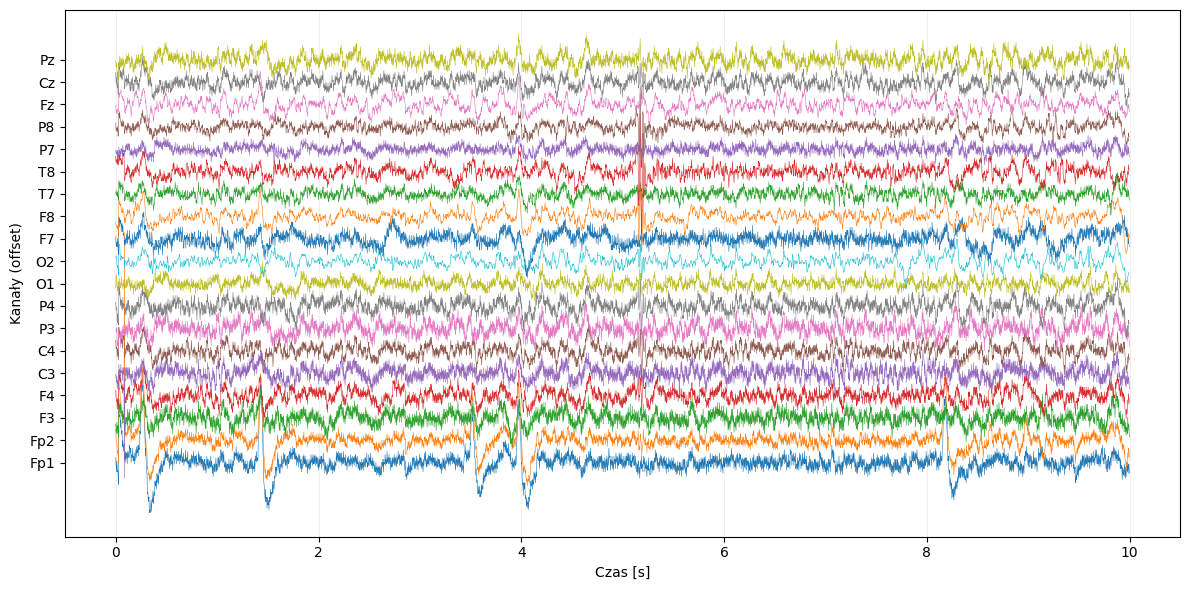

In [32]:
import matplotlib.pyplot as plt
import numpy as np
row = df.loc[df["ID"] == "v10p"].select_dtypes("number").reset_index(drop=True)
seg = row.iloc[: fs * 10]  # pierwsze 10 s
channels = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7',
       'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz']
offset = 500  # µV
t = np.arange(len(seg)) / fs

plt.figure(figsize=(12, 6))
for i, ch in enumerate(channels):
    sig = seg[ch].to_numpy()
    sig = sig - sig.mean()
    plt.plot(t, sig + i*offset, lw=0.4, color=f"C{i%10}")
plt.yticks(np.arange(len(channels))*offset, channels)
plt.xlabel("Czas [s]")
plt.ylabel("Kanały (offset)")
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()


